In [1]:
import pandas as pd

df = pd.read_csv("data/processed/videos_features.csv")

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (205, 26)
['ID', 'Category', 'Channel', 'Title', 'URL', 'Duration', 'Views', 'Explanation_Type', 'Visuals', 'Examples', 'Analogies', 'Real_Life', 'Quality', 'Creator_Takeaways', 'duration_seconds', 'views_numeric', 'combined_text', 'has_analogy', 'has_example', 'has_visual', 'has_math', 'has_code', 'has_application', 'log_views', 'text_length', 'word_count']


In [2]:
text_columns = [
    "Examples",
    "Analogies",
    "Visuals",
    "Real_Life",
    "Creator_Takeaways"
]

for col in text_columns:
    df[col] = df[col].fillna("").astype(str)

df["example_length"] = df["Examples"].str.len()
df["analogy_length"] = df["Analogies"].str.len()
df["visual_length"] = df["Visuals"].str.len()
df["application_length"] = df["Real_Life"].str.len()
df["takeaway_length"] = df["Creator_Takeaways"].str.len()

df[
    [
        "Title",
        "example_length",
        "analogy_length",
        "visual_length",
        "application_length",
        "takeaway_length"
    ]
].head()

,Title,example_length,analogy_length,visual_length,application_length,takeaway_length
0,But what is a neural network? | Deep learning ...,81,133,129,109,124
1,"Gradient descent, how neural networks learn | ...",63,100,94,77,114
2,A Gentle Introduction to Machine Learning,95,101,106,51,95
3,Machine Learning Fundamentals: Bias and Variance,79,109,82,86,98
4,Machine Learning Fundamentals: Cross Validation,72,88,78,64,94


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

support_columns = [
    "example_length",
    "analogy_length",
    "visual_length",
    "application_length",
    "takeaway_length"
]

normalized = scaler.fit_transform(df[support_columns])

df[
    [
        "example_suppor",
        "analogy_support",
        "visual_support",
        "practical_support",
        "takeaway_richness"
    ]
] = normalized

df[
    [
        "Title",
        "example_support",
        "analogy_support",
        "visual_support",
        "practical_support",
        "takeaway_richness"
    ]
].head()

,Title,example_support,analogy_support,visual_support,practical_support,takeaway_richness
0,But what is a neural network? | Deep learning ...,0.476190,0.951807,1.000000,1.000000,1.000000
1,"Gradient descent, how neural networks learn | ...",0.190476,0.554217,0.444444,0.522388,0.818182
2,A Gentle Introduction to Machine Learning,0.698413,0.566265,0.634921,0.134328,0.472727
3,Machine Learning Fundamentals: Bias and Variance,0.444444,0.662651,0.253968,0.656716,0.527273
4,Machine Learning Fundamentals: Cross Validation,0.333333,0.409639,0.190476,0.328358,0.454545


In [4]:
df["explanation_description_richness"] = df[
    [
        "example_support",
        "analogy_support",
        "visual_support",
        "practical_support",
        "takeaway_richness"
    ]
].mean(axis=1)

In [5]:
df[
    [
        "Title",
        "explanation_description_richness"
    ]
].sort_values(
    "explanation_description_richness",
    ascending=False
).head(10)

,Title,explanation_description_richness
0,But what is a neural network? | Deep learning ...,0.885600
143,Faster LLMs: Accelerate Inference with Specula...,0.765904
136,Supercharge Your RAG with Contextualized Late ...,0.741106
201,"What is Multimodal AI? How LLMs Process Text, ...",0.736712
145,What is Low-Rank Adaptation (LoRA) | explained...,0.707840
90,Rerank for better RAG (Explained),0.706987
146,What is YOLO algorithm? | Deep Learning Tutori...,0.690825
86,Advanced RAG techniques for developers,0.682028
83,What is a Vector Database? Powering Semantic S...,0.675739
151,NeRF: Representing Scenes as Neural Radiance F...,0.672299


In [6]:
coverage_columns = [
    "has_visual",
    "has_example",
    "has_analogy",
    "has_application",
    "has_math",
    "has_code"
]

df["content_coverage"] = (
    df[coverage_columns].sum(axis=1)
    / len(coverage_columns)
)

df[
    [
        "Title",
        "has_visual",
        "has_example",
        "has_analogy",
        "has_application",
        "has_math",
        "has_code",
        "content_coverage"
    ]
].head(10)

,Title,has_visual,has_example,has_analogy,has_application,has_math,has_code,content_coverage
0,But what is a neural network? | Deep learning ...,1,1,1,1,1,0,0.833333
1,"Gradient descent, how neural networks learn | ...",1,1,1,1,1,0,0.833333
2,A Gentle Introduction to Machine Learning,1,1,1,1,0,1,0.833333
3,Machine Learning Fundamentals: Bias and Variance,1,1,1,1,0,1,0.833333
4,Machine Learning Fundamentals: Cross Validation,1,1,1,1,0,1,0.833333
5,Machine Learning Fundamentals: The Confusion M...,1,1,1,1,1,1,1.000000
6,"Decision and Classification Trees, Clearly Exp...",1,1,1,1,1,0,0.833333
7,StatQuest: Logistic Regression,1,1,1,1,0,1,0.833333
8,"StatQuest: Random Forests Part 1 - Building, U...",1,1,1,1,0,0,0.666667
9,StatQuest: K-means clustering,1,1,1,1,0,1,0.833333


In [12]:
technical_terms = (
    r"algorithm|architecture|optimization|gradient|"
    r"equation|mathematical|calculus|probability|"
    r"neural network|transformer|embedding|"
    r"python|pytorch|tensorflow|implementation|code|"
    r"loss function|backpropagation|inference"
)

df["technical_terminology_density"] = df["combined_text"].str.count(
    technical_terms,
    flags=2
)

print(df["technical_terminology_density"].describe())

count    205.000000
mean       2.414634
std        2.134860
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: technical_terminology_density, dtype: float64


In [13]:
max_terms = df["technical_terminology_density"].max()

if max_terms > 0:
    df["technical_depth"] = (
        df["technical_terminology_density"] / max_terms
    )
else:
    df["technical_depth"] = 0

df[
    [
        "Title",
        "technical_terminology_density",
        "technical_depth"
    ]
].sort_values(
    "technical_terminology_density",
    ascending=False
).head(10)

,Title,technical_terminology_density,technical_depth
158,Vision Transformer Quick Guide - Theory and Co...,15,1.000000
124,Residual Networks and Skip Connections (DL 15),11,0.733333
188,LoRA: Low-Rank Adaptation of Large Language Mo...,11,0.733333
180,Direct Preference Optimization (DPO) explained...,8,0.533333
1,"Gradient descent, how neural networks learn | ...",7,0.466667
197,Simply Explaining Deep Q-Learning/Deep Q-Netwo...,7,0.466667
130,AutoGen Tutorial 🚀 Create Custom AI Agents EAS...,6,0.400000
90,Rerank for better RAG (Explained),6,0.400000
119,Vision Transformers - Explained!,6,0.400000
40,"Transformers, explained: Understand the model ...",6,0.400000


In [14]:
coverage_summary = df[coverage_columns].mean().sort_values(
    ascending=False
)

print(coverage_summary)

has_visual         1.000000
has_example        1.000000
has_analogy        1.000000
has_application    1.000000
has_code           0.643902
has_math           0.317073
dtype: float64


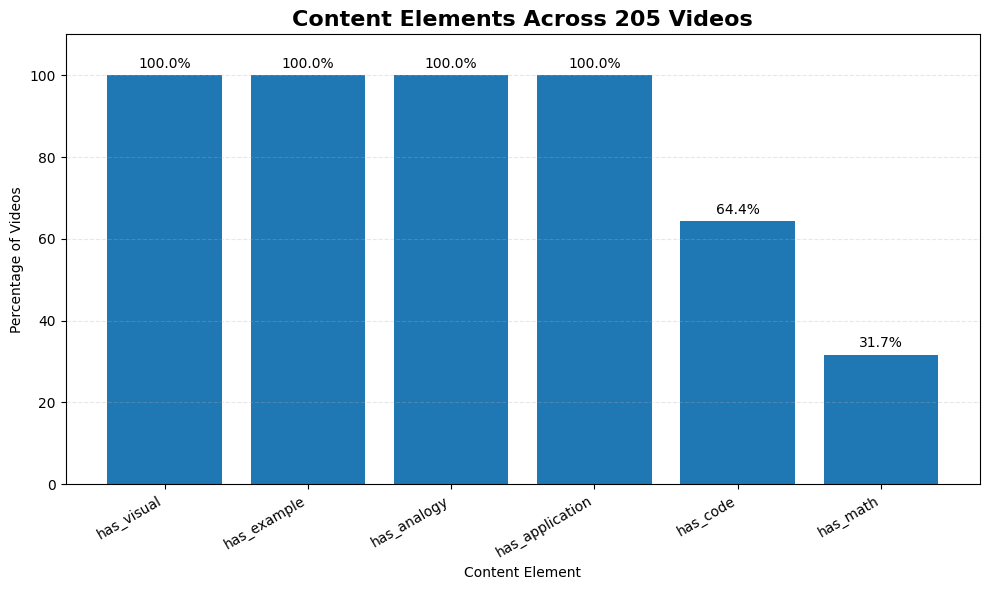

In [17]:
import matplotlib.pyplot as plt
coverage_percent = coverage_summary * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(
    coverage_percent.index,
    coverage_percent.values
)
for bar, value in zip(bars, coverage_percent.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title(
    "Content Elements Across 205 Videos",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Content Element")
plt.ylabel("Percentage of Videos")

plt.ylim(0, 110)

plt.xticks(rotation=30, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [15]:
df["content_coverage"] = (
    df[coverage_columns].sum(axis=1)
    / len(coverage_columns)
)

In [18]:
df["Explanation_Type"].value_counts()

Explanation_Type
Visual Diagrammatic Guide                         2
Fast-Paced Motion Graphic Animation               2
Mathematical & Geometric Intuition                1
Visual Error Decomposition                        1
Step-by-Step Methodological Walkthrough           1
                                                 ..
Algorithmic Deep Dive & Formula Analysis          1
Intuitive Visual Pedagogy                         1
Lightboard Taxonomy & Unification Architecture    1
Conversational Computer Vision Breakdown          1
Systematic Engineering Framework                  1
Name: count, Length: 203, dtype: int64

In [19]:
import numpy as np

embeddings = np.load("data/processed/video_embeddings.npy")

print("Embedding shape:", embeddings.shape)

Embedding shape: (205, 384)


In [20]:
print("Number of videos:", len(df))
print("Number of embeddings:", len(embeddings))

Number of videos: 205
Number of embeddings: 205


In [21]:
from sklearn.preprocessing import normalize

embeddings_normalized = normalize(
    embeddings,
    norm="l2"
)

print("Shape:", embeddings_normalized.shape)

Shape: (205, 384)


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(embeddings_normalized)
    
    score = silhouette_score(
        embeddings_normalized,
        labels
    )
    
    silhouette_scores[k] = score

print("Silhouette Scores:")

for k, score in silhouette_scores.items():
    print(f"K={k}: {score:.4f}")

Silhouette Scores:
K=2: 0.0880
K=3: 0.0879
K=4: 0.0942
K=5: 0.1051
K=6: 0.1116
K=7: 0.1207
K=8: 0.1197
K=9: 0.1219
K=10: 0.1218


In [23]:
final_k = 9

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    embeddings_normalized
)

df["cluster"] = cluster_labels

print(df["cluster"].value_counts().sort_index())

cluster
0    39
1    26
2    38
3    26
4    21
5    12
6    10
7    15
8    18
Name: count, dtype: int64


In [24]:
for cluster_id in sorted(df["cluster"].unique()):
    print(f"\n===== CLUSTER {cluster_id} =====")
    
    display(
        df[df["cluster"] == cluster_id][
            [
                "Title",
                "Category",
                "Explanation_Type"
            ]
        ].head(10)
    )


===== CLUSTER 0 =====


,Title,Category,Explanation_Type
0,But what is a neural network? | Deep learning ...,Machine Learning (ML),Mathematical & Geometric Intuition
1,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),Mathematical Optimization & Geometry
2,A Gentle Introduction to Machine Learning,Machine Learning (ML),Pedagogical First-Principles Breakdown
3,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),Visual Error Decomposition
4,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),Step-by-Step Methodological Walkthrough
5,Machine Learning Fundamentals: The Confusion M...,Machine Learning (ML),Analytical Metric Derivation
6,"Decision and Classification Trees, Clearly Exp...",Machine Learning (ML),Hierarchical Logic & Splitting Math
7,StatQuest: Logistic Regression,Machine Learning (ML),Probabilistic Curve Fitting
8,"StatQuest: Random Forests Part 1 - Building, U...",Machine Learning (ML),Ensemble Learning & Bagging
9,StatQuest: K-means clustering,Machine Learning (ML),Iterative Clustering Algorithm



===== CLUSTER 1 =====


,Title,Category,Explanation_Type
55,Large Language Models explained briefly,Large Language Models (LLM),Conceptual & Philosophical Deconstruction
56,[1hr Talk] Intro to Large Language Models,Large Language Models (LLM),Masterclass Systems Engineering
57,Deep Dive into LLMs like ChatGPT,Large Language Models (LLM),Exhaustive End-to-End Technical Deep Dive
58,How Large Language Models Work,Large Language Models (LLM),Concise Conceptual Lightboard Lecture
59,Prompt Engineering Tutorial – Master ChatGPT a...,Large Language Models (LLM),Tactical Hands-on Implementation Guide
60,Google's 9 Hour AI Prompt Engineering Course I...,Large Language Models (LLM),Curriculum Synthesis & Study Guide
62,How ChatGPT Works Technically | ChatGPT Archit...,Large Language Models (LLM),System Architecture Animation
63,What is Mixture of Experts?,Large Language Models (LLM),Sparse Architecture & Router Network
67,LangChain Explained in 13 Minutes | QuickStart...,Large Language Models (LLM),Framework Architecture & Quickstart
68,LangChain Crash Course For Beginners | LangCha...,Large Language Models (LLM),Comprehensive Project Tutorial



===== CLUSTER 2 =====


...

,Title,Category,Explanation_Type
64,Reinforcement Learning with Human Feedback (RL...,Large Language Models (LLM),Probabilistic Alignment Walkthrough
152,Q Learning Explained (tutorial),Reinforcement Learning & Game Theory,High-Energy Interactive Tutorial
153,Deep Q-Networks Explained!,Reinforcement Learning & Game Theory,Neural Network Integration & Stability Tricks
154,Proximal Policy Optimization (PPO) for LLMs Ex...,Reinforcement Learning & Game Theory,Mathematical Pedagogy for AI Practitioners
195,Q-Learning Explained - Reinforcement Learning ...,Reinforcement Learning & Game Theory,Clean Motion Graphics Tutorial
196,Q-Learning: Model Free Reinforcement Learning ...,Reinforcement Learning & Game Theory,Engineering Mathematics Lecture
197,Simply Explaining Deep Q-Learning/Deep Q-Netwo...,Reinforcement Learning & Game Theory,Code-First PyTorch Walkthrough
198,Deep Q-Learning - Combining Neural Networks an...,Reinforcement Learning & Game Theory,Curriculum-Aligned Step-by-Step Lesson
199,Proximal Policy Optimization | ChatGPT uses this,Reinforcement Learning & Game Theory,Algorithmic Deep Dive & Formula Analysis
200,Proximal Policy Optimization Explained,Reinforcement Learning & Game Theory,Intuitive Visual Pedagogy



===== CLUSTER 7 =====


,Title,Category,Explanation_Type
61,Optimize Your AI - Quantization Explained,Large Language Models (LLM),Hardware & Model Compression Breakdown
65,How KV Cache Speeds Up LLMs for Faster AI Mode...,Large Language Models (LLM),Inference Optimization & Memory Footprint
75,How LLMs survive in low precision | Quantizati...,Large Language Models (LLM),Hardware & Mathematical Engineering
79,The KV Cache: Memory Usage in Transformers,Large Language Models (LLM),GPU Systems Deep Dive
122,MAMBA and State Space Models explained | SSM e...,Advanced Neural Architectures,Theoretical Deep-Dive & Hardware-Aware Algorithms
142,How FlashAttention Accelerates Generative AI R...,LLM Systems & Inference Optimization,GPU Architecture & Hardware Tiling
144,What is vLLM? Efficient AI Inference for Large...,LLM Systems & Inference Optimization,Systems Infrastructure & PagedAttention
145,What is Low-Rank Adaptation (LoRA) | explained...,LLM Systems & Inference Optimization,Primary Source Mathematical Intuition
163,MAMBA from Scratch: Neural Nets Better and Fas...,Advanced Neural Architectures,First-Principles Software Engineering
180,Direct Preference Optimization (DPO) explained...,LLM Systems & Inference Optimization,Rigorous Mathematical Paper Derivation



===== CLUSTER 8 =====


,Title,Category,Explanation_Type
108,But how do AI images and videos actually work?...,Generative AI & Diffusion Models,Mathematical Intuition & Visual Manim Animations
118,Vision Transformers Explained | The ViT Paper,Advanced Neural Architectures,Concise Paper Architecture Summary
119,Vision Transformers - Explained!,Advanced Neural Architectures,Deep Technical Walkthrough with Math
146,What is YOLO algorithm? | Deep Learning Tutori...,Computer Vision & Multimodal AI,Object Detection Grid Architecture
147,How computers learn to recognize objects insta...,Computer Vision & Multimodal AI,Inspiring Visionary Keynote Demo
148,SAM - Segment Anything Model by Meta AI: Compl...,Computer Vision & Multimodal AI,Foundation Model Architecture & Python Demo
150,What Are Vision Language Models? How AI Sees &...,Computer Vision & Multimodal AI,Multimodal Lightboard Architecture
151,NeRF: Representing Scenes as Neural Radiance F...,Computer Vision & Multimodal AI,In-Depth Paper Review & Volumetric Rendering
158,Vision Transformer Quick Guide - Theory and Co...,Advanced Neural Architectures,Theory + PyTorch Code Implementation
159,Vision Transformer,Advanced Neural Architectures,Micro-Animation Architecture Primer


In [25]:
cluster_category = pd.crosstab(
    df["cluster"],
    df["Category"]
)

cluster_category

Category,Advanced Neural Architectures,Advanced Retrieval & Search,Agentic AI & Multi-Agent Systems,Computer Vision & Multimodal AI,Generative AI & Diffusion Models,LLM Systems & Inference Optimization,Large Language Models (LLM),Machine Learning (ML),Natural Language Processing (NLP),Reinforcement Learning & Game Theory,Retrieval-Augmented Generation (RAG)
cluster,,,,,,,,,,,
0,7,0,0,2,0,0,0,30,0,0,0
1,1,0,0,0,0,7,18,0,0,0,0
2,0,10,0,0,0,0,0,0,0,0,28
3,0,0,0,0,0,0,1,0,25,0,0
4,0,1,19,0,0,0,1,0,0,0,0
5,0,0,0,0,12,0,0,0,0,0,0
6,0,0,0,0,0,0,1,0,0,9,0
7,2,0,0,0,0,9,4,0,0,0,0
8,5,0,0,12,1,0,0,0,0,0,0


In [26]:
cluster_category_percentage = pd.crosstab(
    df["cluster"],
    df["Category"],
    normalize="index"
) * 100

cluster_category_percentage.round(1)

Category,Advanced Neural Architectures,Advanced Retrieval & Search,Agentic AI & Multi-Agent Systems,Computer Vision & Multimodal AI,Generative AI & Diffusion Models,LLM Systems & Inference Optimization,Large Language Models (LLM),Machine Learning (ML),Natural Language Processing (NLP),Reinforcement Learning & Game Theory,Retrieval-Augmented Generation (RAG)
cluster,,,,,,,,,,,
0,17.9,0.0,0.0,5.1,0.0,0.0,0.0,76.9,0.0,0.0,0.0
1,3.8,0.0,0.0,0.0,0.0,26.9,69.2,0.0,0.0,0.0,0.0
2,0.0,26.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73.7
3,0.0,0.0,0.0,0.0,0.0,0.0,3.8,0.0,96.2,0.0,0.0
4,0.0,4.8,90.5,0.0,0.0,0.0,4.8,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,90.0,0.0
7,13.3,0.0,0.0,0.0,0.0,60.0,26.7,0.0,0.0,0.0,0.0
8,27.8,0.0,0.0,66.7,5.6,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(
    df["Category"],
    df["cluster"]
)

nmi = normalized_mutual_info_score(
    df["Category"],
    df["cluster"]
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.7033
Normalized Mutual Information (NMI): 0.8081


In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

embeddings_2d = pca.fit_transform(
    embeddings_normalized
)

print("Original shape:", embeddings_normalized.shape)
print("Reduced shape:", embeddings_2d.shape)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original shape: (205, 384)
Reduced shape: (205, 2)
Explained variance: [0.10717113 0.07243   ]
Total explained variance: 0.17960113


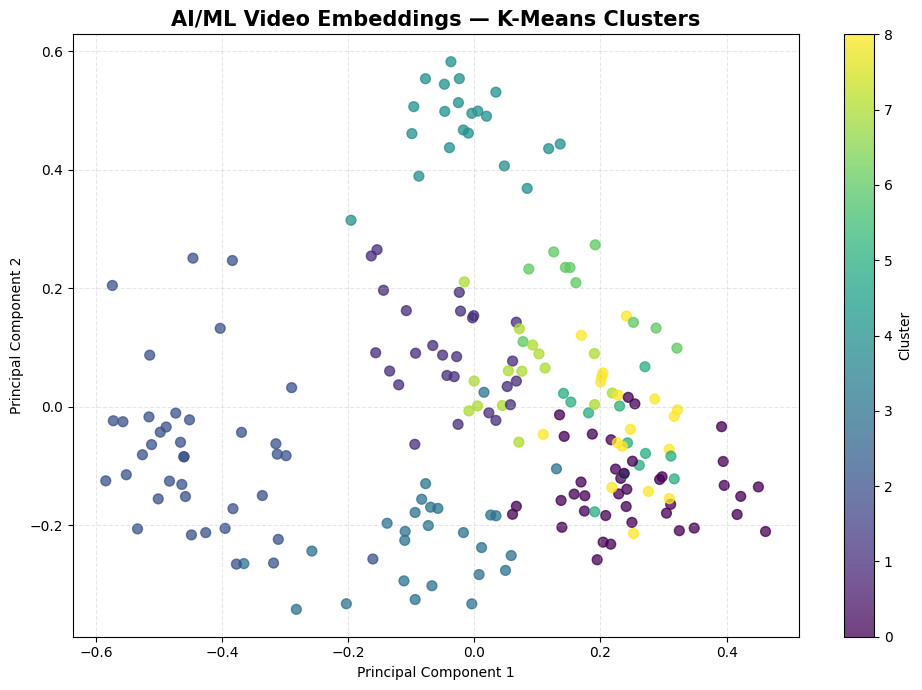

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["cluster"],
    s=50,
    alpha=0.75
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "AI/ML Video Embeddings — K-Means Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

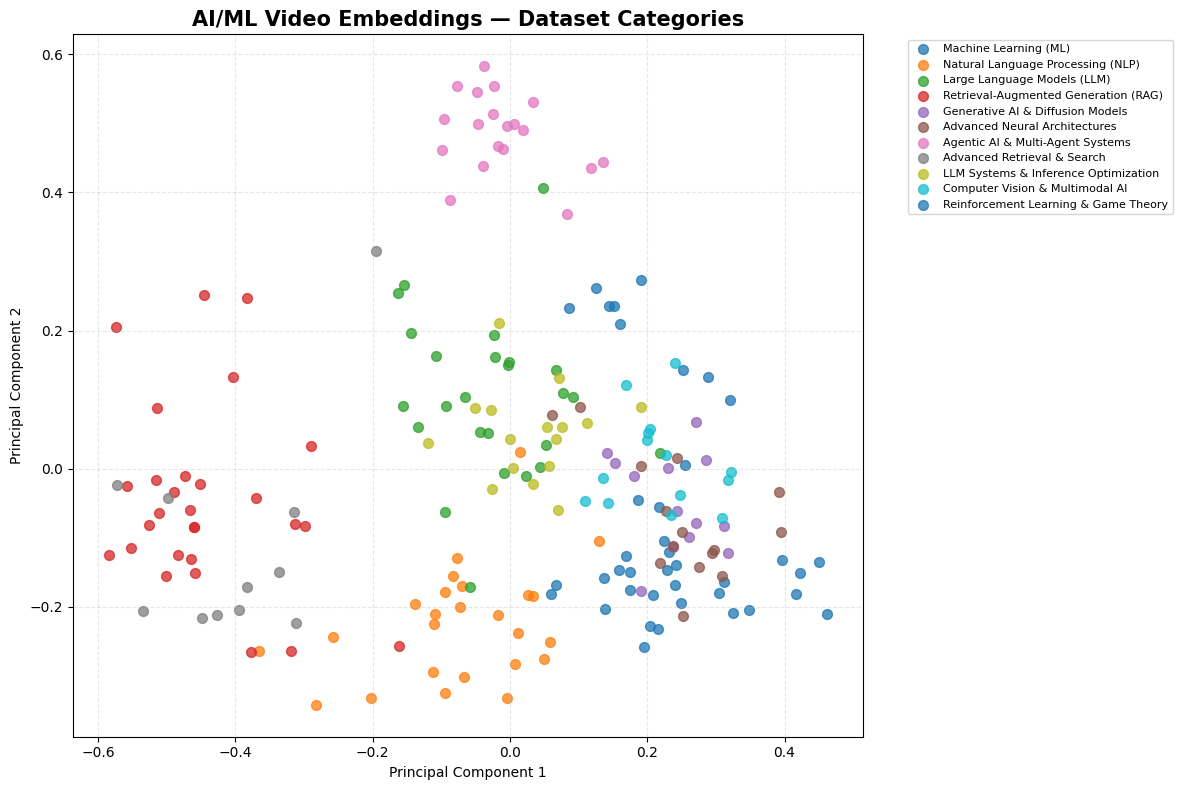

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

categories = df["Category"].unique()

for category in categories:
    mask = df["Category"] == category
    
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        s=50,
        alpha=0.75,
        label=category
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "AI/ML Video Embeddings — Dataset Categories",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [32]:
df.to_csv(
    "data/processed/videos_clustered.csv",
    index=False
)

print("Saved:", df.shape)

Saved: (205, 42)


In [33]:
np.save(
    "data/processed/video_embeddings_normalized.npy",
    embeddings_normalized
)

print("Normalized embeddings saved.")

Normalized embeddings saved.
